In [37]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#-----------data preprocessing------------
df=pd.read_csv("Network_log.csv")
df.info()    #to get datastructure information

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 16 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Timestamp            2910 non-null   object 
 1   Source_IP            2850 non-null   object 
 2   Destination_IP       3000 non-null   object 
 3   Source_Port          3000 non-null   int64  
 4   Destination_Port     3000 non-null   int64  
 5   Protocol             3000 non-null   object 
 6   Packet_Size          2760 non-null   float64
 7   Connection_Duration  2820 non-null   float64
 8   Packets_Per_Second   2760 non-null   float64
 9   Error_Rate           2820 non-null   float64
 10  Login_Attempts       3000 non-null   int64  
 11  Bytes_Sent           2760 non-null   float64
 12  Bytes_Received       2760 non-null   float64
 13  Traffic_Flag         3000 non-null   object 
 14  MAC_Address          2850 non-null   object 
 15  Label                3000 non-null   i

In [39]:
df.describe()   #to get statistical information

,Source_Port,Destination_Port,Packet_Size,Connection_Duration,Packets_Per_Second,Error_Rate,Login_Attempts,Bytes_Sent,Bytes_Received,Label
count,3000.000000,3000.000000,2760.000000,2820.000000,2760.000000,2820.000000,3000.000000,2760.000000,2760.000000,3000.000000
mean,33207.699333,1405.190667,1021.607971,402.711702,2980.267754,0.500984,12.086000,30472.977536,35534.315942,0.389667
std,18724.665241,2928.193129,569.840459,232.806543,1747.642955,0.289940,7.213826,17161.569435,20096.278263,0.487756
min,1028.000000,21.000000,40.000000,1.000000,1.000000,0.000575,0.000000,160.000000,152.000000,0.000000
25%,17147.000000,22.000000,544.750000,200.000000,1423.000000,0.252721,6.000000,15998.500000,17995.500000,0.000000
50%,32645.500000,53.000000,1006.000000,400.000000,2971.000000,0.496149,12.000000,30472.500000,36347.000000,0.000000
75%,49354.250000,443.000000,1521.000000,607.500000,4508.000000,0.753080,18.000000,45421.750000,52677.500000,1.000000
max,65530.000000,8080.000000,1999.000000,799.000000,5996.000000,0.999897,24.000000,59994.000000,69986.000000,1.000000


In [40]:
df.isnull().sum()  # to check null values in each column

Timestamp               90
Source_IP              150
Destination_IP           0
Source_Port              0
Destination_Port         0
Protocol                 0
Packet_Size            240
Connection_Duration    180
Packets_Per_Second     240
Error_Rate             180
Login_Attempts           0
Bytes_Sent             240
Bytes_Received         240
Traffic_Flag             0
MAC_Address            150
Label                    0
dtype: int64

In [41]:
# handle null values in timestamp column
df['Timestamp'] = df['Timestamp'].ffill()
#handle null values in Source IP and Mac Address
df['Source_IP']=df['Source_IP'].fillna("Unknown")
df['MAC_Address']=df['MAC_Address'].fillna("Unknown")
#handling null values in numerical datatype columns
col=['Packet_Size','Connection_Duration','Error_Rate','Packets_Per_Second','Bytes_Sent','Bytes_Received']
for c in col:
    df[c]=df[c].fillna(df[c].median())
df.isnull().sum()   #null values handled successfully

Timestamp              0
Source_IP              0
Destination_IP         0
Source_Port            0
Destination_Port       0
Protocol               0
Packet_Size            0
Connection_Duration    0
Packets_Per_Second     0
Error_Rate             0
Login_Attempts         0
Bytes_Sent             0
Bytes_Received         0
Traffic_Flag           0
MAC_Address            0
Label                  0
dtype: int64

In [43]:
#converting timestamp datatype
df['Timestamp']=pd.to_datetime(df['Timestamp'])
# Extract features
df['Hour'] = df['Timestamp'].dt.hour
df['Day'] = df['Timestamp'].dt.day
df['Month'] = df['Timestamp'].dt.month
# Remove original column
df.drop('Timestamp', axis=1, inplace=True)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 18 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Source_IP            3000 non-null   object 
 1   Destination_IP       3000 non-null   object 
 2   Source_Port          3000 non-null   int64  
 3   Destination_Port     3000 non-null   int64  
 4   Protocol             3000 non-null   object 
 5   Packet_Size          3000 non-null   float64
 6   Connection_Duration  3000 non-null   float64
 7   Packets_Per_Second   3000 non-null   float64
 8   Error_Rate           3000 non-null   float64
 9   Login_Attempts       3000 non-null   int64  
 10  Bytes_Sent           3000 non-null   float64
 11  Bytes_Received       3000 non-null   float64
 12  Traffic_Flag         3000 non-null   object 
 13  MAC_Address          3000 non-null   object 
 14  Label                3000 non-null   int64  
 15  Hour                 3000 non-null   i

In [44]:
#encoding categorical features
from sklearn.preprocessing import LabelEncoder
le1=LabelEncoder()
df['Protocol']=le1.fit_transform(df['Protocol'])    #encoding protocol column 


In [45]:
le2=LabelEncoder()
df['Traffic_Flag']=le2.fit_transform(df['Traffic_Flag'])  #encoding traffic_flag column 


In [46]:
#drop IP Address and MAC Address column as they do not contribute further in our Model training
df.drop(['Source_IP','Destination_IP','MAC_Address'], axis=1, inplace=True)  
print(df)

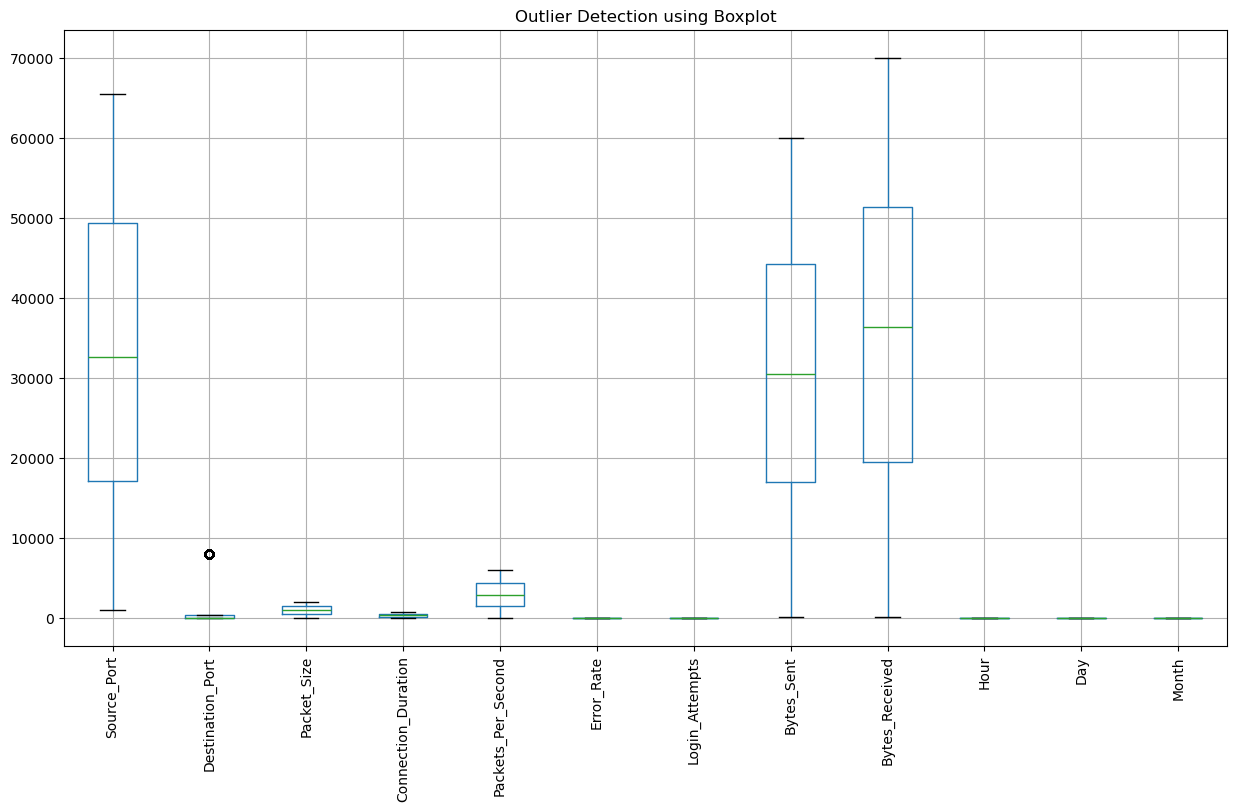

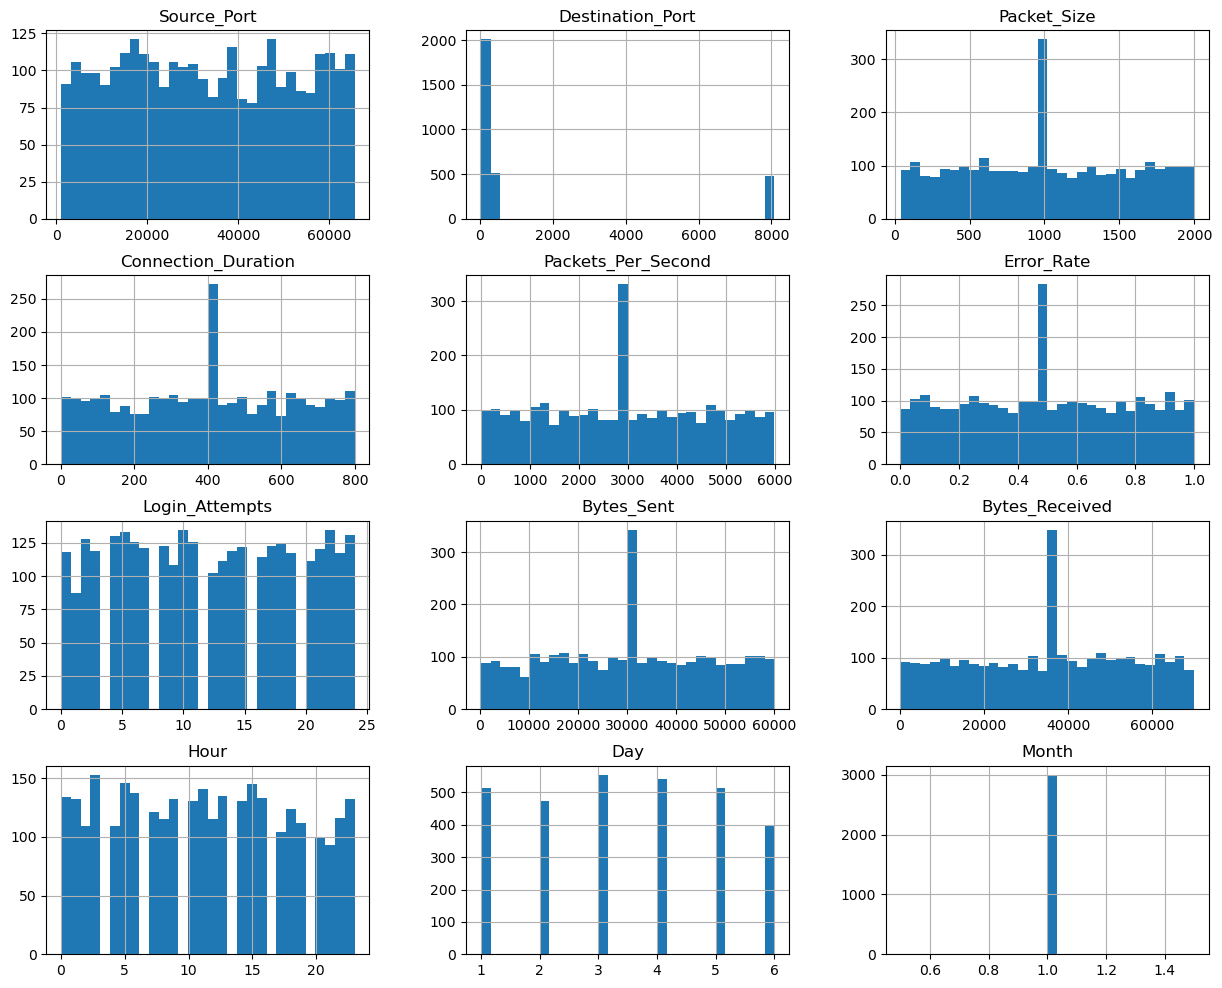

In [48]:
num_cols = df.select_dtypes(include=np.number).columns.tolist()
# remove categorical numeric columns
num_cols.remove('Protocol')
num_cols.remove('Traffic_Flag')
num_cols.remove('Label')

#boxplot visualization for outliers
plt.figure(figsize=(15,8))
df[num_cols].boxplot(rot=90)
plt.title("Outlier Detection using Boxplot")
plt.show()

#distribution visualization
df[num_cols].hist(figsize=(15,12), bins=30)
plt.show()

In [49]:
def count_outliers(df):    #to check outliers using iqr method
    for col in num_cols:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        iqr = Q3 - Q1

        lower = Q1 - 1.5 * iqr
        upper = Q3 + 1.5 * iqr

        count = ((df[col] < lower) | (df[col] > upper)).sum()
        print(f"{col}: {count} outliers")

count_outliers(df)

Source_Port: 0 outliers
Destination_Port: 483 outliers
Packet_Size: 0 outliers
Connection_Duration: 0 outliers
Packets_Per_Second: 0 outliers
Error_Rate: 0 outliers
Login_Attempts: 0 outliers
Bytes_Sent: 0 outliers
Bytes_Received: 0 outliers
Hour: 0 outliers
Day: 0 outliers
Month: 0 outliers


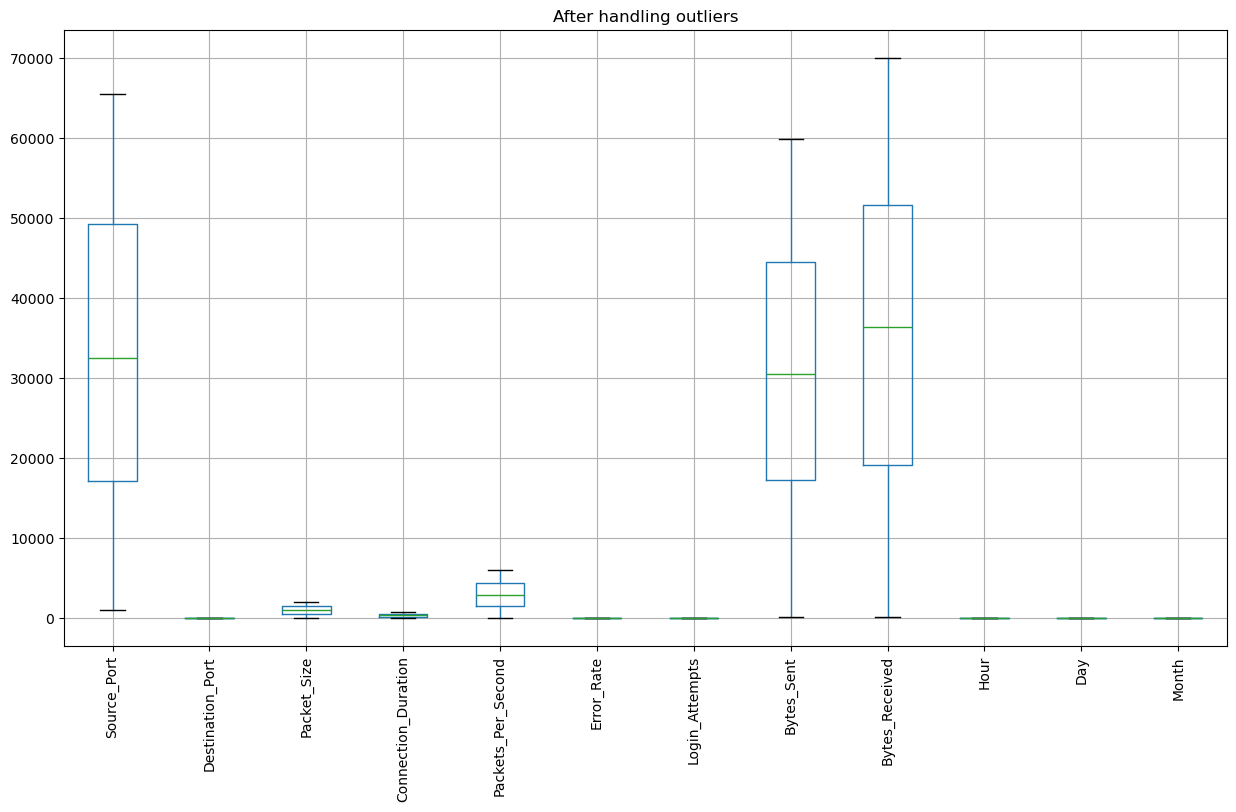

In [53]:
#to remove outliers 
q1 = df['Destination_Port'].quantile(0.25)
q3 = df['Destination_Port'].quantile(0.75)
iqr=q3-q1
lower = q1 - 1.5 * iqr
upper = q3 + 1.5 * iqr
df = df[(df['Destination_Port'] >= lower) & (df['Destination_Port'] <= upper)]

plt.figure(figsize=(15,8))
df[num_cols].boxplot(rot=90)
plt.title("After handling outliers")
plt.show()

In [54]:
# correlation matrix
corr_matrix = df.corr(numeric_only=True)
corr_matrix

,Source_Port,Destination_Port,Protocol,Packet_Size,Connection_Duration,Packets_Per_Second,Error_Rate,Login_Attempts,Bytes_Sent,Bytes_Received,Traffic_Flag,Label,Hour,Day,Month
Source_Port,1.000000,0.017553,0.009760,-0.011587,-0.006264,-0.015687,-0.015850,0.031170,-0.011636,-0.035888,0.005012,0.027280,-0.004237,0.025915,NaN
Destination_Port,0.017553,1.000000,0.026135,-0.034438,-0.002692,0.025428,-0.022793,0.013108,0.008725,0.008846,0.011642,-0.003125,0.022720,0.036943,NaN
Protocol,0.009760,0.026135,1.000000,-0.042266,0.039605,0.002455,0.023628,-0.053185,0.001862,-0.026320,0.045047,-0.040409,-0.020950,0.017491,NaN
Packet_Size,-0.011587,-0.034438,-0.042266,1.000000,0.039727,0.001760,-0.006285,0.018745,0.002441,-0.010044,0.020217,0.121043,-0.016645,-0.013632,NaN
Connection_Duration,-0.006264,-0.002692,0.039605,0.039727,1.000000,-0.008074,-0.023185,0.025341,0.032986,0.017397,-0.017178,0.027182,-0.018914,-0.022576,NaN
Packets_Per_Second,-0.015687,0.025428,0.002455,0.001760,-0.008074,1.000000,-0.012155,0.024218,0.010746,-0.006604,0.015976,0.034673,0.013429,0.011801,NaN
Error_Rate,-0.015850,-0.022793,0.023628,-0.006285,-0.023185,-0.012155,1.000000,0.004242,-0.013683,0.002679,0.003569,0.099416,0.006012,0.038201,NaN
Login_Attempts,0.031170,0.013108,-0.053185,0.018745,0.025341,0.024218,0.004242,1.000000,0.001213,-0.021890,0.004374,0.520238,-0.015606,0.003688,NaN
Bytes_Sent,-0.011636,0.008725,0.001862,0.002441,0.032986,0.010746,-0.013683,0.001213,1.000000,0.042039,-0.018145,0.079687,0.043921,-0.029146,NaN
Bytes_Received,-0.035888,0.008846,-0.026320,-0.010044,0.017397,-0.006604,0.002679,-0.021890,0.042039,1.000000,-0.004339,-0.012618,0.025097,-0.012025,NaN


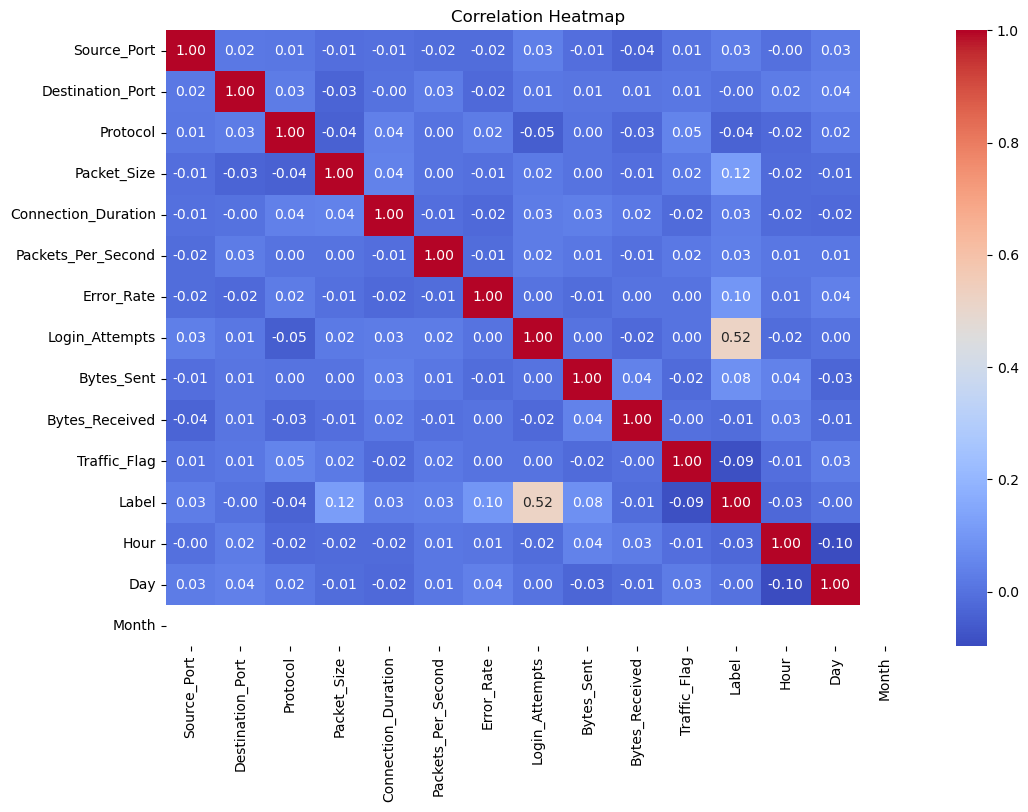

In [55]:
#visualization using heatmap
plt.figure(figsize=(12,8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

In [65]:
#removing unnecssary features from dataset
# ---- numeric correlation selection ----
corr = df.corr(numeric_only=True)["Label"]
numeric_features = corr[abs(corr) >= 0.05].index.tolist()
print("Numeric Selected:", numeric_features)
# ---- manually add important categorical feature ----
categorical_features = ["Connection_Duration",'Packets_Per_Second']
# combine features
selected_features = list(set(numeric_features + categorical_features))
print("Final Selected Features:", selected_features)

# keep only selected columns
df = df[selected_features]
print(df)

Numeric Selected: ['Packet_Size', 'Error_Rate', 'Login_Attempts', 'Bytes_Sent', 'Traffic_Flag', 'Label']
Final Selected Features: ['Bytes_Sent', 'Label', 'Packets_Per_Second', 'Error_Rate', 'Connection_Duration', 'Packet_Size', 'Traffic_Flag', 'Login_Attempts']
      Bytes_Sent  Label  Packets_Per_Second  Error_Rate  Connection_Duration  \
1        30472.5      0              2971.0    0.632884                687.0   
2         3537.0      0              3112.0    0.412128                559.0   
5        38758.0      0              4770.0    0.905415                594.0   
8         3023.0      1              5137.0    0.657357                124.0   
9        47259.0      0              1278.0    0.235127                160.0   
...          ...    ...                 ...         ...                  ...   
2990     10536.0      1              1347.0    0.837095                580.0   
2992     37744.0      0              1791.0    0.233600                528.0   
2993     32228.0  

In [69]:
#feature scaling(Standarisation)
from sklearn.preprocessing import StandardScaler
ss=StandardScaler()
x=df.drop('Label',axis=1)
y=df['Label']
x_scaled=ss.fit_transform(x)
print(x_scaled[:5])

[[-0.0154281  -0.0155043   0.47764526  1.28512541 -0.02462361 -0.34338589
   0.38215587]
 [-1.65032436  0.06852524 -0.3025826   0.71266244  0.56205092  0.8439846
  -0.03299435]
 [ 0.4874745   1.05661732  1.4408685   0.86919528 -0.08734982  0.8439846
   0.10538906]
 [-1.68152247  1.27533252  0.56414405 -1.23281719 -0.10764359 -0.34338589
   1.48922314]
 [ 1.00345724 -1.02445478 -0.92816855 -1.07181198  0.82586997  0.8439846
  -0.30976117]]


In [71]:
from sklearn.model_selection import train_test_split
#Train-test split
x_train, x_test, y_train, y_test= train_test_split(x_scaled, y, test_size=0.2, random_state=4)

In [73]:
df.to_csv("Processed_data.csv",index=False)
